# 02 — Results synthesis

Loads every results JSON / summary the analysis scripts emit and assembles the headline tables and figures for Chapter 5 of the dissertation. This notebook is an archival synthesis aid; the submitted thesis and tracked JSON artefacts are the source of truth. It is designed to be re-runnable: each cell handles a missing input file by reporting `PENDING` and skipping.

## Coverage

| Cell | Thesis section | Source(s) |
|---|---|---|
| §5.1 | Replication study | `results/checkpoints/<exp>_summary.json` |
| §5.2 | Threshold sweep + model selection | `results/classical/threshold_sweep_<tag>.json` |
| §5.3 | Hough post-processing | `results/classical/hough_postprocess_<tag>.json` |
| §5.4 | Confidence intervals | `results/classical/bootstrap_<tag>.json` |
| §5.5 | Two-stage detector | `results/classical/two_stage_<tag>.json` |
| §5.6 | Data efficiency | `results/checkpoints/unet_data_efficiency_f<frac>_s2804_summary.json` |

The deviations-from-the-paper table is **not** reproduced here: `report/thesis.tex` Table 6.1 is its single source of truth.

## Status legend

- **OK** — input found, table/figure produced.
- **PENDING** — input not found (locked artefact absent, or downstream study not run).
- **PARTIAL** — some inputs found.

## Conventions

- All paths are relative to the project root `bg492/`.
- The notebook does **not** mutate any results files.
- Figures intended for the thesis are also saved under `results/figures/` so they can be referenced from `thesis.tex` independently of this notebook.

In [1]:
from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Project root — notebook lives in bg492/notebooks/, so go up one.
PROJECT_ROOT = Path('..').resolve()
RESULTS_DIR = PROJECT_ROOT / 'results'
CHECKPOINTS_DIR = RESULTS_DIR / 'checkpoints'
CLASSICAL_DIR = RESULTS_DIR / 'classical'
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Locked final experiment and public result tag.
STUDY_NAME = 'winner_t44_s2804'
WINNER_EXPERIMENT_NAME = 'unet_paper_arch_noise_topk_t44_s2804'

# Reference paper metrics (Stoppa et al. 2024, threshold=0.58, 20k-patch test set).
PAPER = {
    'precision': 0.94,
    'recall': 0.94,
    'fnr_pre_hough': 0.0698,
    'fnr_post_hough': 0.0338,
}

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

In [2]:
def load_json(path: Path) -> dict | None:
    """Return the parsed JSON at ``path`` or ``None`` if it does not exist."""
    if not path.exists():
        return None
    return json.loads(path.read_text())


def find_one(pattern: str, root: Path) -> Path | None:
    """Return the single matching path under ``root`` or ``None``.

    If multiple match, returns the most recently modified.
    """
    matches = sorted(root.glob(pattern), key=lambda p: p.stat().st_mtime)
    return matches[-1] if matches else None


@dataclass
class CellStatus:
    name: str
    state: str  # 'OK', 'PENDING', 'PARTIAL'
    detail: str = ''

    def banner(self) -> Markdown:
        return Markdown(f'**{self.state}** — {self.detail}')


def show(status: CellStatus, df: pd.DataFrame | None = None) -> None:
    display(status.banner())
    if df is not None:
        display(df)


def fmt(value: float | None, places: int = 4) -> str:
    return '—' if value is None else f'{value:.{places}f}'

## §5.1 Replication study

Loads `<WINNER_EXPERIMENT_NAME>_summary.json` and reports the headline validation and test metrics next to the Stoppa et al.\ 2024 reference values. The summary JSON is written by `src/training/train_unet.py` and includes both the validation history and the optional final-test block.

**PARTIAL** — validation history present but test metrics absent (skip_test_eval=True or test pass not yet run)

,metric,this work,Stoppa 2024
0,val_dice (best),0.8559,—
1,val_loss (best epoch),0.0219,—


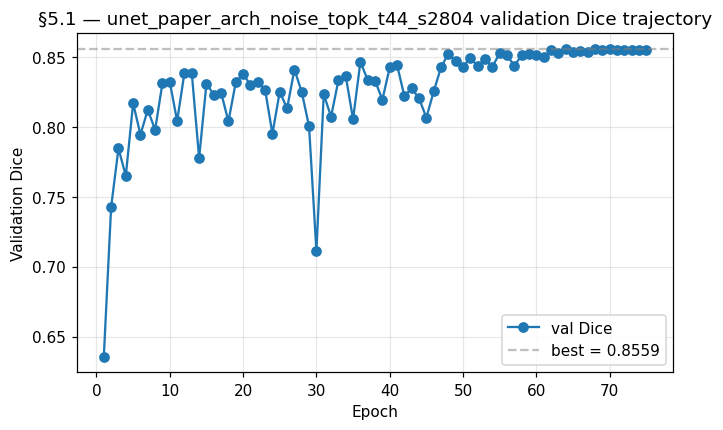

saved results/figures/fig_5_1_val_dice_trajectory.png


In [3]:
summary_path = CHECKPOINTS_DIR / f'{WINNER_EXPERIMENT_NAME}_summary.json'
summary = load_json(summary_path)

if summary is None:
    show(CellStatus('5.1', 'PENDING', f'expected {summary_path.relative_to(PROJECT_ROOT)} (locked winner summary not found)'))
else:
    history = pd.DataFrame(summary['history'])
    test_metrics = summary.get('test_metrics')
    best_val_dice = float(history['val_dice'].max()) if not history.empty else None

    rows = [
        {'metric': 'val_dice (best)', 'this work': fmt(best_val_dice), 'Stoppa 2024': '—'},
        {'metric': 'val_loss (best epoch)', 'this work': fmt(float(history.loc[history['val_dice'].idxmax(), 'val_loss']) if best_val_dice is not None else None), 'Stoppa 2024': '—'},
    ]
    if test_metrics:
        rows.extend([
            {'metric': 'test_precision', 'this work': fmt(test_metrics['precision']), 'Stoppa 2024': fmt(PAPER['precision'])},
            {'metric': 'test_recall',    'this work': fmt(test_metrics['recall']),    'Stoppa 2024': fmt(PAPER['recall'])},
            {'metric': 'test_dice',      'this work': fmt(test_metrics['dice']),      'Stoppa 2024': '—'},
            {'metric': 'test_iou',       'this work': fmt(test_metrics['iou']),       'Stoppa 2024': '—'},
        ])
        state = 'OK'
        detail = f'best epoch {summary.get("effective_eval_max_batches", "all")} batches; test metrics present'
    else:
        state = 'PARTIAL'
        detail = 'validation history present but test metrics absent (skip_test_eval=True or test pass not yet run)'

    show(CellStatus('5.1', state, detail), pd.DataFrame(rows))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history['epoch'], history['val_dice'], marker='o', label='val Dice')
    if best_val_dice is not None:
        ax.axhline(best_val_dice, linestyle='--', color='grey', alpha=0.5, label=f'best = {best_val_dice:.4f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Dice')
    ax.set_title(f'§5.1 — {WINNER_EXPERIMENT_NAME} validation Dice trajectory')
    ax.legend()
    out = FIGURES_DIR / 'fig_5_1_val_dice_trajectory.png'
    fig.savefig(out)
    plt.show()
    print(f'saved {out.relative_to(PROJECT_ROOT)}')

## §5.2 Threshold sweep and model selection

Loads `results/classical/threshold_sweep_<tag>.json` (produced by `scripts/threshold_sweep.py`) and reports the validation F1-optimal threshold plus the PR curve. The sweep should be run against the **validation** split only; the chosen threshold is then locked before test evaluation.

**OK** — loaded results/classical/threshold_sweep_winner_t44_s2804.json

,metric,value
0,optimal_threshold,0.450
1,val_f1 (at opt),0.8565
2,val_precision,0.8439
3,val_recall,0.8696
4,test_precision,0.8517
5,test_recall,0.9180
6,test_dice,0.8836


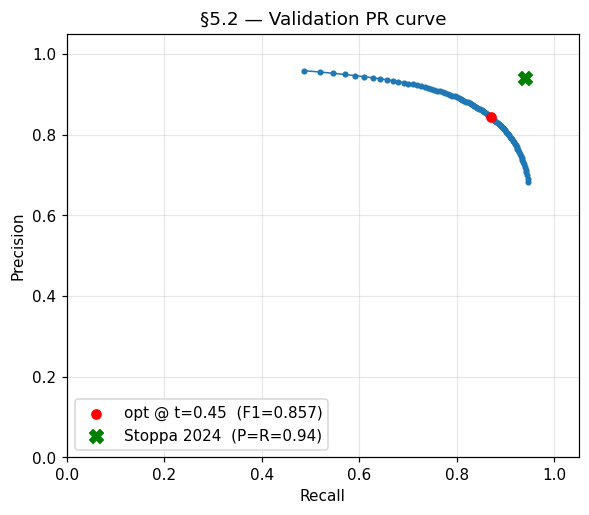

saved results/figures/fig_5_2_pr_curve.png


In [4]:
sweep_path = CLASSICAL_DIR / f'threshold_sweep_{STUDY_NAME}.json'
if not sweep_path.exists():
    sweep_path = find_one(f'threshold_sweep_{STUDY_NAME}*.json', CLASSICAL_DIR)

if sweep_path is None:
    show(CellStatus('5.2', 'PENDING', f'no threshold_sweep_{STUDY_NAME}*.json in {CLASSICAL_DIR.relative_to(PROJECT_ROOT)}'))
else:
    sweep = load_json(sweep_path)
    pr = pd.DataFrame(sweep['pr_curve'])
    opt_t = sweep['optimal_threshold']

    summary_rows = [
        {'metric': 'optimal_threshold', 'value': fmt(opt_t, 3)},
        {'metric': 'val_f1 (at opt)',   'value': fmt(sweep['val_f1'])},
        {'metric': 'val_precision',     'value': fmt(sweep['val_precision'])},
        {'metric': 'val_recall',        'value': fmt(sweep['val_recall'])},
    ]
    if 'test_precision' in sweep:
        summary_rows.extend([
            {'metric': 'test_precision', 'value': fmt(sweep['test_precision'])},
            {'metric': 'test_recall',    'value': fmt(sweep['test_recall'])},
            {'metric': 'test_dice',      'value': fmt(sweep['test_dice'])},
        ])
    show(CellStatus('5.2', 'OK', f'loaded {sweep_path.relative_to(PROJECT_ROOT)}'), pd.DataFrame(summary_rows))

    required_pr_cols = {'threshold', 'precision', 'recall', 'f1'}
    if pr.empty or not required_pr_cols.issubset(pr.columns):
        show(CellStatus('5.2 plot', 'PENDING', 'no validation PR curve in this fixed-threshold artefact'))
    else:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(pr['recall'], pr['precision'], marker='.', linewidth=1)
        opt_row = pr.loc[pr['threshold'].sub(opt_t).abs().idxmin()]
        ax.scatter([opt_row['recall']], [opt_row['precision']], color='red', zorder=5,
                   label=f'opt @ t={opt_t:.2f}  (F1={opt_row["f1"]:.3f})')
        ax.scatter([PAPER['recall']], [PAPER['precision']], color='green', marker='X', s=80,
                   zorder=4, label=f'Stoppa 2024  (P=R={PAPER["precision"]})')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title('§5.2 — Validation PR curve')
        ax.set_xlim(0, 1.05)
        ax.set_ylim(0, 1.05)
        ax.legend(loc='lower left')
        out = FIGURES_DIR / 'fig_5_2_pr_curve.png'
        fig.savefig(out)
        plt.show()
        print(f'saved {out.relative_to(PROJECT_ROOT)}')

## §5.3 Hough post-processing

Loads the Hough post-processing JSON (produced by `scripts/hough_postprocess.py`) and reports image-level, patch-level and pixel-level FNR before and after the probabilistic Hough recovery step, next to the Stoppa reference figures (6.98 % → 3.38 %).

**OK** — loaded results/classical/hough_postprocess_winner_t44_s2804_parity.json (checkpoint=unet_paper_arch_noise_topk_t44_s2804_best.pth)

,level,pre,post,paper pre,paper post
0,image (n+=31),0.0000,0.0000,0.0698,0.0338
1,patch (n+=872),0.1216,0.1032,—,—
2,pixel recall,0.9180,0.9895,—,—


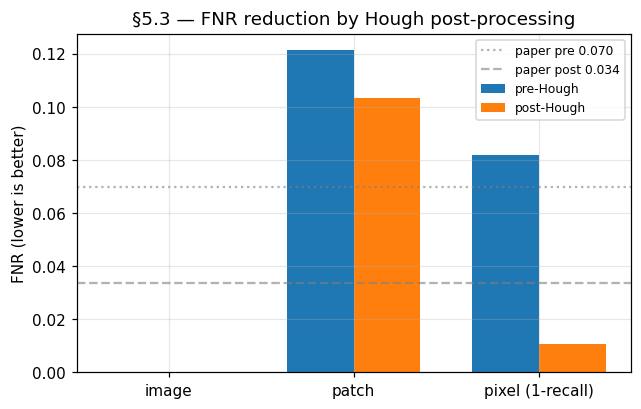

saved results/figures/fig_5_3_hough_fnr.png


In [5]:
hough_path = find_one(f'hough_postprocess_{STUDY_NAME}*.json', CLASSICAL_DIR) or find_one('hough_postprocess_*.json', CLASSICAL_DIR)

if hough_path is None:
    show(CellStatus('5.3', 'PENDING', 'no hough_postprocess_*.json found; run scripts/hough_postprocess.py against the locked checkpoint'))
else:
    h = load_json(hough_path)
    rows = [
        {'level':   'image (n+={})'.format(h['n_positive_images']),
         'pre':     fmt(h['fnr_pre_hough']),
         'post':    fmt(h['fnr_post_hough']),
         'paper pre':  fmt(PAPER['fnr_pre_hough']),
         'paper post': fmt(PAPER['fnr_post_hough'])},
        {'level':   'patch (n+={})'.format(h['n_positive_patches']),
         'pre':     fmt(h['fnr_pre_patch']),
         'post':    fmt(h['fnr_post_patch']),
         'paper pre': '—', 'paper post': '—'},
        {'level':   'pixel recall',
         'pre':     fmt(h['pixel_recall_pre']),
         'post':    fmt(h['pixel_recall_post']),
         'paper pre': '—', 'paper post': '—'},
    ]
    show(CellStatus('5.3', 'OK', f'loaded {hough_path.relative_to(PROJECT_ROOT)} (checkpoint={Path(h["checkpoint"]).name})'),
         pd.DataFrame(rows))

    levels = ['image', 'patch', 'pixel (1-recall)']
    pre = [h['fnr_pre_hough'] or 0, h['fnr_pre_patch'] or 0, 1 - (h['pixel_recall_pre'] or 0)]
    post = [h['fnr_post_hough'] or 0, h['fnr_post_patch'] or 0, 1 - (h['pixel_recall_post'] or 0)]
    x = np.arange(len(levels))
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.bar(x - 0.18, pre, 0.36, label='pre-Hough')
    ax.bar(x + 0.18, post, 0.36, label='post-Hough')
    ax.axhline(PAPER['fnr_pre_hough'], color='grey', linestyle=':', alpha=0.6, label=f'paper pre {PAPER["fnr_pre_hough"]:.3f}')
    ax.axhline(PAPER['fnr_post_hough'], color='grey', linestyle='--', alpha=0.6, label=f'paper post {PAPER["fnr_post_hough"]:.3f}')
    ax.set_xticks(x)
    ax.set_xticklabels(levels)
    ax.set_ylabel('FNR (lower is better)')
    ax.set_title('§5.3 — FNR reduction by Hough post-processing')
    ax.legend(loc='upper right', fontsize=8)
    out = FIGURES_DIR / 'fig_5_3_hough_fnr.png'
    fig.savefig(out)
    plt.show()
    print(f'saved {out.relative_to(PROJECT_ROOT)}')

## §5.4 Confidence intervals

Loads `results/classical/bootstrap_<tag>.json` (produced by `scripts/bootstrap_metrics.py`) and reports the cluster-bootstrap (image-resampled) and patch-bootstrap CIs for precision, recall, Dice and IoU.

**OK** — loaded results/classical/bootstrap_winner_t44_s2804.json (n_resamples=1000, n_images=32)

,metric,point,cluster CI,patch CI
0,precision,0.8517,"[0.8056, 0.8906]","[0.8387, 0.8643]"
1,recall,0.9180,"[0.8876, 0.9461]","[0.9094, 0.9264]"
2,dice,0.8836,"[0.8567, 0.9042]","[0.8756, 0.8917]"
3,iou,0.7915,"[0.7493, 0.8252]","[0.7788, 0.8046]"


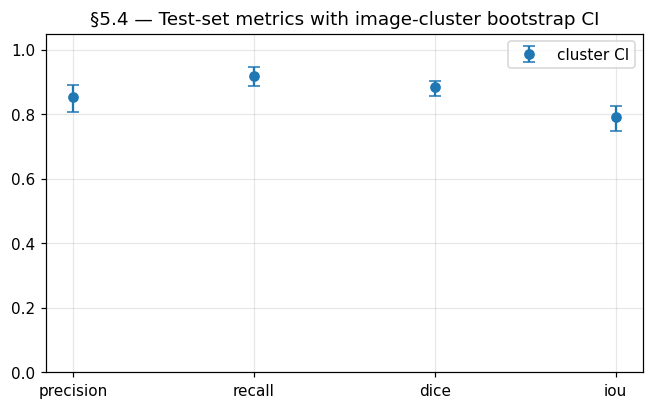

saved results/figures/fig_5_4_bootstrap_ci.png


In [6]:
boot_path = find_one(f'bootstrap_{STUDY_NAME}*.json', CLASSICAL_DIR) or find_one('bootstrap_*.json', CLASSICAL_DIR)

if boot_path is None:
    show(CellStatus('5.4', 'PENDING', 'no bootstrap_*.json found; run scripts/bootstrap_metrics.py against the locked checkpoint'))
else:
    b = load_json(boot_path)
    metrics = list(b['point_metrics'].keys())
    rows = []
    for m in metrics:
        pt = b['point_metrics'][m]
        cl = b['cluster_bootstrap'][m]
        pa = b['patch_bootstrap'][m]
        rows.append({
            'metric':           m,
            'point':            fmt(pt),
            'cluster CI':       f'[{fmt(cl["lo"])}, {fmt(cl["hi"])}]',
            'patch CI':         f'[{fmt(pa["lo"])}, {fmt(pa["hi"])}]',
        })
    show(CellStatus('5.4', 'OK', f'loaded {boot_path.relative_to(PROJECT_ROOT)} (n_resamples={b["n_resamples"]}, n_images={b["n_source_images"]})'),
         pd.DataFrame(rows))

    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(metrics))
    points = [b['point_metrics'][m] for m in metrics]
    cl_lo = [b['cluster_bootstrap'][m]['lo'] for m in metrics]
    cl_hi = [b['cluster_bootstrap'][m]['hi'] for m in metrics]
    yerr_lo = [p - lo for p, lo in zip(points, cl_lo)]
    yerr_hi = [hi - p for p, hi in zip(points, cl_hi)]
    ax.errorbar(x, points, yerr=[yerr_lo, yerr_hi], fmt='o', capsize=4, label='cluster CI')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.set_title('§5.4 — Test-set metrics with image-cluster bootstrap CI')
    ax.legend()
    out = FIGURES_DIR / 'fig_5_4_bootstrap_ci.png'
    fig.savefig(out)
    plt.show()
    print(f'saved {out.relative_to(PROJECT_ROOT)}')

## §5.5 Two-stage detector

Loads `results/classical/two_stage_<tag>.json` (produced by `src/inference/two_stage.py`). The cell reports the classifier operating point, U-Net metrics on routed patches, end-to-end metrics (with classifier-rejected positives counted as FN), and the compute-saving fraction.

In [7]:
ts_path = find_one('two_stage_*.json', CLASSICAL_DIR)

if ts_path is None:
    show(CellStatus('5.5', 'PENDING', 'no two_stage_*.json found; run src/inference/two_stage.py for the locked checkpoint'))
else:
    t = load_json(ts_path)
    rows = [
        {'group': 'classifier', 'metric': 'threshold',    'value': fmt(t.get('classifier_threshold'), 3)},
        {'group': 'classifier', 'metric': 'recall',       'value': fmt(t.get('classifier_recall'))},
        {'group': 'classifier', 'metric': 'precision',    'value': fmt(t.get('classifier_precision'))},
        {'group': 'classifier', 'metric': 'fnr',          'value': fmt(t.get('classifier_fnr'))},
        {'group': 'classifier', 'metric': 'patches_routed_fraction',
                                'value': fmt(t.get('patches_routed_fraction'))},
        {'group': 'U-Net on routed', 'metric': 'precision', 'value': fmt(t.get('unet_precision_on_routed'))},
        {'group': 'U-Net on routed', 'metric': 'recall',    'value': fmt(t.get('unet_recall_on_routed'))},
        {'group': 'U-Net on routed', 'metric': 'dice',      'value': fmt(t.get('unet_dice_on_routed'))},
        {'group': 'end-to-end', 'metric': 'precision', 'value': fmt(t.get('end_to_end_precision'))},
        {'group': 'end-to-end', 'metric': 'recall',    'value': fmt(t.get('end_to_end_recall'))},
        {'group': 'end-to-end', 'metric': 'dice',      'value': fmt(t.get('end_to_end_dice'))},
        {'group': 'end-to-end + Hough', 'metric': 'fnr_pre',  'value': fmt(t.get('hough_end_to_end_fnr_pre'))},
        {'group': 'end-to-end + Hough', 'metric': 'fnr_post', 'value': fmt(t.get('hough_end_to_end_fnr_post'))},
        {'group': 'baseline U-Net (single-stage)', 'metric': 'precision', 'value': fmt(t.get('baseline_unet_precision'))},
        {'group': 'baseline U-Net (single-stage)', 'metric': 'recall',    'value': fmt(t.get('baseline_unet_recall'))},
        {'group': 'baseline U-Net (single-stage)', 'metric': 'dice',      'value': fmt(t.get('baseline_unet_dice'))},
    ]
    show(CellStatus('5.5', 'OK', f'loaded {ts_path.relative_to(PROJECT_ROOT)}'), pd.DataFrame(rows))

**OK** — loaded results/classical/two_stage_t44_s2804.json

,group,metric,value
0,classifier,threshold,0.180
1,classifier,recall,0.9037
2,classifier,precision,0.3002
3,classifier,fnr,0.0963
4,classifier,patches_routed_fraction,0.7526
5,U-Net on routed,precision,0.8637
6,U-Net on routed,recall,0.9210
7,U-Net on routed,dice,0.8915
8,end-to-end,precision,0.8637
9,end-to-end,recall,0.9137


## §5.6 Data efficiency

Loads `<exp>_summary.json` for the 30 / 50 / 70 % training-fraction reruns of the locked winning config and the full-data baseline, then plots validation Dice (and test Dice if available) vs the number of training images.

**OK** — 4/4 fractions loaded

,fraction,val_dice_best,test_dice,path
0,30%,0.8424,—,results/checkpoints/unet_data_efficiency_f30_s...
1,50%,0.8424,—,results/checkpoints/unet_data_efficiency_f50_s...
2,70%,0.8537,—,results/checkpoints/unet_data_efficiency_f70_s...
3,full,0.8559,—,results/checkpoints/unet_paper_arch_noise_topk...


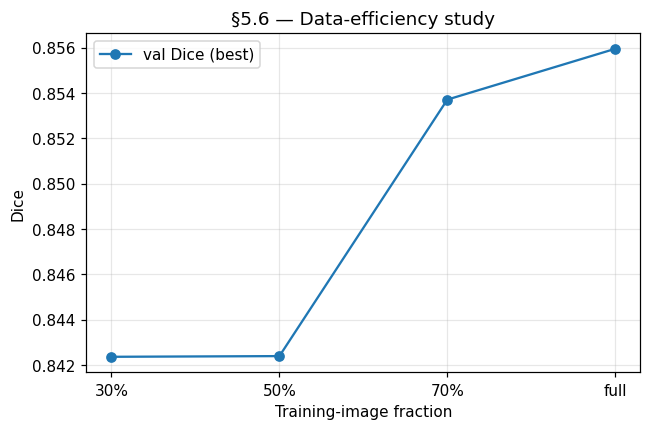

saved results/figures/fig_5_6_data_efficiency.png


In [8]:
fractions = [0.30, 0.50, 0.70, 1.00]
rows: list[dict[str, Any]] = []
for f in fractions:
    if f == 1.00:
        path = CHECKPOINTS_DIR / f'{WINNER_EXPERIMENT_NAME}_summary.json'
        tag = 'full'
    else:
        path = CHECKPOINTS_DIR / f'unet_data_efficiency_f{int(f * 100)}_s2804_summary.json'
        tag = f'{int(f * 100)}%'
    payload = load_json(path)
    if payload is None:
        rows.append({'fraction': tag, 'val_dice_best': None, 'test_dice': None, 'path': str(path.relative_to(PROJECT_ROOT))})
        continue
    history = pd.DataFrame(payload['history'])
    rows.append({
        'fraction': tag,
        'val_dice_best': float(history['val_dice'].max()) if not history.empty else None,
        'test_dice': (payload.get('test_metrics') or {}).get('dice'),
        'path': str(path.relative_to(PROJECT_ROOT)),
    })
df = pd.DataFrame(rows)
loaded = df['val_dice_best'].notna().sum()
state = 'OK' if loaded == len(fractions) else ('PARTIAL' if loaded > 0 else 'PENDING')
detail = f'{loaded}/{len(fractions)} fractions loaded' + (' — reruns incomplete for locked winner' if loaded < len(fractions) else '')
show(CellStatus('5.6', state, detail), df.assign(
    val_dice_best=df['val_dice_best'].map(lambda v: fmt(v)),
    test_dice=df['test_dice'].map(lambda v: fmt(v)),
))

if loaded > 0:
    plot_df = df.dropna(subset=['val_dice_best'])
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(plot_df['fraction'], plot_df['val_dice_best'], marker='o', label='val Dice (best)')
    if plot_df['test_dice'].notna().any():
        ax.plot(plot_df['fraction'], plot_df['test_dice'], marker='s', linestyle='--', label='test Dice')
    ax.set_xlabel('Training-image fraction')
    ax.set_ylabel('Dice')
    ax.set_title('§5.6 — Data-efficiency study')
    ax.legend()
    out = FIGURES_DIR / 'fig_5_6_data_efficiency.png'
    fig.savefig(out)
    plt.show()
    print(f'saved {out.relative_to(PROJECT_ROOT)}')

---

_Re-run after each new artefact lands in `results/`. Figures saved under `results/figures/` are the canonical files referenced from `report/thesis.tex`; the inline figures here are previews._